In [1]:
!pip install -U transformers


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
from PIL import Image
import requests
from io import BytesIO
from transformers import CLIPProcessor, CLIPModel  # 수정: CLIPVisionModel → CLIPModel


c:\Users\ehjun\Documents\데브코스\dev_cor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("object-detection", model="valentinafeve/yolos-fashionpedia")

c:\Users\ehjun\Documents\데브코스\AIModel\AI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


NameError: name 'torch' is not defined

In [4]:
# Load model directly
from transformers import AutoImageProcessor, AutoModelForObjectDetection

processor = AutoImageProcessor.from_pretrained("valentinafeve/yolos-fashionpedia")
model = AutoModelForObjectDetection.from_pretrained("valentinafeve/yolos-fashionpedia")

ImportError: 
AutoImageProcessor requires the PIL library but it was not found in your environment. You can install it with pip:
`pip install pillow`. Please note that you may need to restart your runtime after installation.


In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("zero-shot-image-classification", model="patrickjohncyh/fashion-clip")
pipe(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/hub/parrots.png",
    candidate_labels=["animals", "humans", "landscape"],
)

c:\Users\ehjun\Documents\데브코스\dev_cor\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ehjun\.cache\huggingface\hub\models--patrickjohncyh--fashion-clip. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 662.53it/s, Materializing param=visual_projecti

[{'score': 0.9981828331947327, 'label': 'animals'},
 {'score': 0.0011912648333236575, 'label': 'humans'},
 {'score': 0.0006259088404476643, 'label': 'landscape'}]

In [ ]:
# Load model directly
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification

processor = AutoProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model = AutoModelForZeroShotImageClassification.from_pretrained("patrickjohncyh/fashion-clip")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 639.11it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# import torch
# from PIL import Image
# import requests
# from io import BytesIO
# from transformers import CLIPProcessor, CLIPModel  # 수정: CLIPVisionModel → CLIPModel


# from transformers import (
#     AutoImageProcessor,
#     AutoModelForObjectDetection,
# )


# YOLOS_ID = "valentinafeve/yolos-fashionpedia"         # 의류 object detection [web:140]
# FCLIP_ID = "patrickjohncyh/fashion-clip"              # fashion domain CLIP [web:153]


# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# # Fashionpedia 라벨들 중, 의류 카테고리에 해당하는 것들만 추려서 사용 [web:141][web:173]
# TOP_LABELS = {
#     "shirt, blouse",
#     "top, t-shirt, sweatshirt",
#     "sweater",
#     "cardigan",
#     "jacket",
#     "vest",
#     "coat",
# }


# BOTTOM_LABELS = {
#     "pants",
#     "shorts",
#     "skirt",
#     "dress",
#     "jumpsuit",
# }


# def load_image(img_path_or_url: str) -> Image.Image:
#     """로컬 경로 또는 URL 입력을 받아 PIL 이미지로 로드"""
#     if img_path_or_url.startswith("http://") or img_path_or_url.startswith("https://"):
#         r = requests.get(img_path_or_url, timeout=30)
#         r.raise_for_status()
#         return Image.open(BytesIO(r.content)).convert("RGB")
#     return Image.open(img_path_or_url).convert("RGB")


# def pick_allowed_labels(korean_category: str):
#     if korean_category == "상의":
#         return TOP_LABELS
#     if korean_category == "하의":
#         return BOTTOM_LABELS
#     # 그 외는 필요에 맞게
#     return TOP_LABELS | BOTTOM_LABELS


# @torch.no_grad()
# def detect_clothes_and_crop(
#     image: Image.Image,
#     image_processor,
#     det_model,
#     score_thresh: float = 0.5,
#     pad: int = 10,
#     topk: int = 5,
# ):
#     """
#     YOLOS로 박스 검출 후 크롭
#     """
#     det_model.eval()

#     inputs = image_processor(images=image, return_tensors="pt")
#     inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

#     outputs = det_model(**inputs)

#     # HuggingFace object detection은 post_process_object_detection로
#     # 원본 이미지 크기 기준 bbox로 변환하는 패턴이 일반적임.
#     target_sizes = torch.tensor([image.size[::-1]], device=DEVICE)  # (h, w)
#     results = image_processor.post_process_object_detection(
#         outputs, threshold=score_thresh, target_sizes=target_sizes
#     )[0]

#     boxes = results["boxes"].detach().cpu()   # (N, 4) in (x1, y1, x2, y2)
#     scores = results["scores"].detach().cpu()
#     labels = results["labels"].detach().cpu()

#     # 점수 높은 순으로 topk만
#     if len(scores) == 0:
#         return []

#     order = torch.argsort(scores, descending=True)[:topk]
#     crops = []

#     W, H = image.size
#     for i in order:
#         x1, y1, x2, y2 = boxes[i].tolist()

#         # 약간 여백 주기
#         x1 = max(0, int(x1) - pad)
#         y1 = max(0, int(y1) - pad)
#         x2 = min(W, int(x2) + pad)
#         y2 = min(H, int(y2) + pad)

#         crop = image.crop((x1, y1, x2, y2))
#         crops.append(
#             {
#                 "crop": crop,
#                 "score": float(scores[i]),
#                 "label_id": int(labels[i]),
#                 "box_xyxy": (x1, y1, x2, y2),
#             }
#         )

#     return crops


# @torch.no_grad()
# def embed_images_with_fashionclip(crop_images, clip_processor, clip_model, l2_normalize=True):
#     """
#     Fashion-CLIP으로 이미지 임베딩 추출.
#     """
#     clip_model.eval()
#     embeddings = []

#     for item in crop_images:
#         img = item["crop"]
#         inputs = clip_processor(images=img, return_tensors="pt")
#         inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

#         # 핵심 수정: get_image_features() 사용 (이미지 임베딩만 추출)
#         emb = clip_model.get_image_features(pixel_values=inputs["pixel_values"])  # (1, dim)
#         emb = emb[0].detach().cpu()

#         if l2_normalize:
#             emb = emb / (emb.norm(p=2) + 1e-12)

#         embeddings.append({**item, "embedding": emb})

#     return embeddings


# def run(image_path_or_url: str, score_thresh=0.5):
#     # 1) 모델 로드
#     image_processor = AutoImageProcessor.from_pretrained(YOLOS_ID)
#     det_model = AutoModelForObjectDetection.from_pretrained(YOLOS_ID).to(DEVICE)

#     # 수정: CLIPModel 전체 사용
#     clip_processor = CLIPProcessor.from_pretrained(FCLIP_ID)
#     clip_model = CLIPModel.from_pretrained(FCLIP_ID).to(DEVICE)  # VisionModel → CLIPModel

#     # 2) 이미지 로드
#     image = load_image(image_path_or_url)

#     # 3) 검출 후 크롭
#     crops = detect_clothes_and_crop(
#         image=image,
#         image_processor=image_processor,
#         det_model=det_model,
#         score_thresh=score_thresh,
#         pad=10,
#         topk=5,
#     )

#     if not crops:
#         print("No detections above threshold.")
#         return []

#     # 4) 크롭 이미지 임베딩 추출
#     results = embed_images_with_fashionclip(crops, clip_processor, clip_model)  # clip_vision_model → clip_model

#     # 결과 예시 출력
#     for i, r in enumerate(results):
#         print(f"[{i}] score={r['score']:.3f} label_id={r['label_id']} box={r['box_xyxy']} emb_dim={r['embedding'].shape[0]}")

#     return results


# if __name__ == "__main__":
#     # 로컬 파일 경로 or URL
#     out = run(r"C:\Users\ehjun\Documents\데브코스\AIModel\data\image\coat\01_sou_000003_000011_front_01outer_01coat_woman.jpg", score_thresh=0.6)
#     # out[n]["crop"] : PIL 이미지(크롭 결과)
#     # out[n]["embedding"] : torch 텐서(임베딩 벡터)


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 922.46it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0] score=0.992 label_id=31 box=(50, 140, 406, 731) emb_dim=1
[1] score=0.981 label_id=31 box=(725, 149, 964, 757) emb_dim=1
[2] score=0.960 label_id=28 box=(435, 55, 682, 204) emb_dim=1
[3] score=0.905 label_id=32 box=(305, 532, 500, 594) emb_dim=1
[4] score=0.693 label_id=9 box=(51, 66, 978, 1010) emb_dim=1


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 496.81it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0] score=0.992 label_id=31 box=(50, 140, 406, 731) emb_dim=1
[1] score=0.981 label_id=31 box=(725, 149, 964, 757) emb_dim=1
[2] score=0.960 label_id=28 box=(435, 55, 682, 204) emb_dim=1
[3] score=0.905 label_id=32 box=(305, 532, 500, 594) emb_dim=1
[4] score=0.693 label_id=9 box=(51, 66, 978, 1010) emb_dim=1


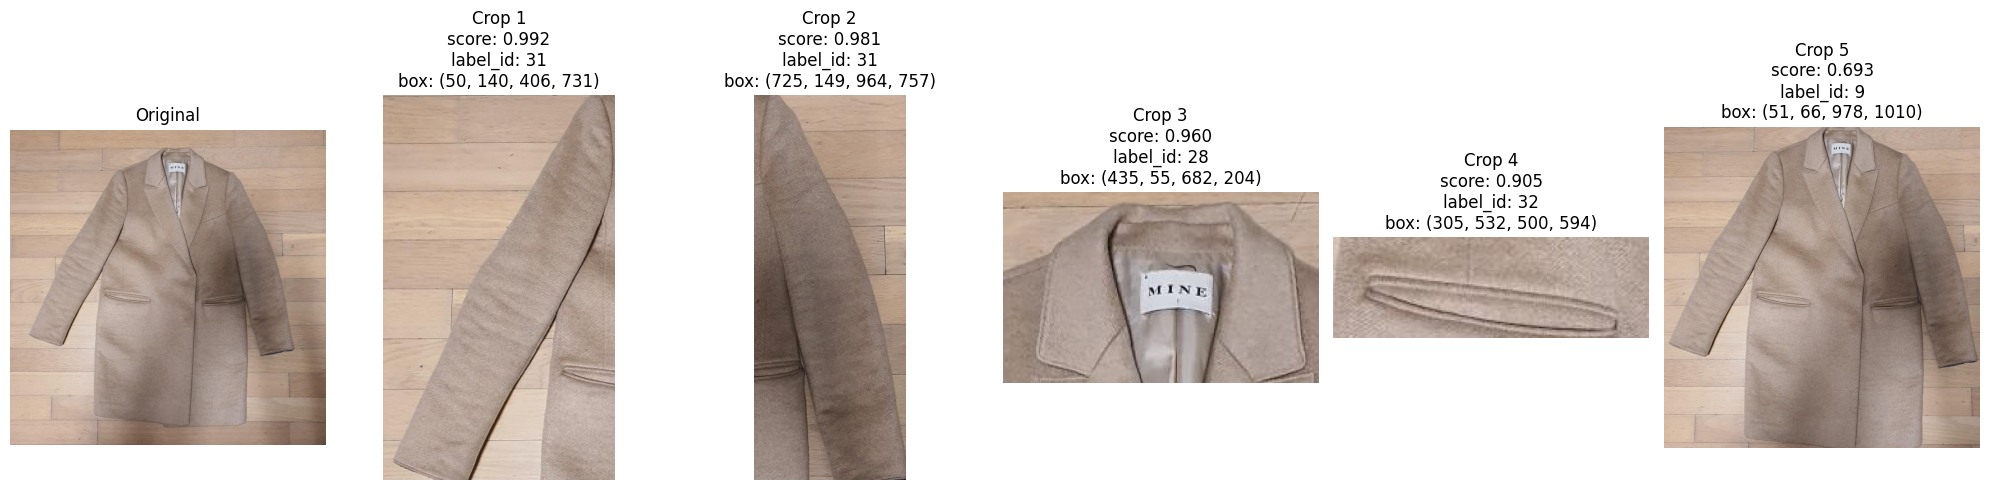

In [ ]:
# import matplotlib.pyplot as plt
# import os

# out = run(r"C:\Users\ehjun\Documents\데브코스\AIModel\data\image\coat\01_sou_000003_000011_front_01outer_01coat_woman.jpg", score_thresh=0.6)

# # 원본 + 크롭들 표시
# fig, axs = plt.subplots(1, len(out)+1, figsize=(20, 5))

# # 원본 이미지
# original_path = r"C:\Users\ehjun\Documents\데브코스\AIModel\data\image\coat\01_sou_000003_000011_front_01outer_01coat_woman.jpg"
# original = load_image(original_path)
# axs[0].imshow(original)
# axs[0].set_title('Original')
# axs[0].axis('off')

# # 크롭들
# for i, result in enumerate(out):
#     axs[i+1].imshow(result["crop"])
#     axs[i+1].set_title(f'Crop {i+1}\nscore: {result["score"]:.3f}\nlabel_id: {result["label_id"]}\nbox: {result["box_xyxy"]}')
#     axs[i+1].axis('off')

# plt.tight_layout()
# plt.show()


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 877.45it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0] score=0.996 label_id=31 box=(185, 332, 256, 507) emb_dim=1
[1] score=0.993 label_id=31 box=(344, 367, 400, 532) emb_dim=1
[2] score=0.986 label_id=6 box=(201, 483, 389, 970) emb_dim=1
[3] score=0.983 label_id=23 box=(222, 959, 296, 1056) emb_dim=1
[4] score=0.978 label_id=23 box=(312, 882, 426, 951) emb_dim=1


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1026.38it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0] score=0.982 label_id=31 box=(359, 337, 430, 458) emb_dim=1
[1] score=0.948 label_id=33 box=(389, 328, 479, 383) emb_dim=1
[2] score=0.928 label_id=23 box=(424, 920, 519, 1015) emb_dim=1
[3] score=0.919 label_id=6 box=(369, 502, 520, 979) emb_dim=1
[4] score=0.841 label_id=1 box=(354, 326, 525, 540) emb_dim=1


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 996.32it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[0] score=0.999 label_id=31 box=(172, 342, 241, 456) emb_dim=1
[1] score=0.997 label_id=31 box=(357, 330, 429, 440) emb_dim=1
[2] score=0.988 label_id=33 box=(241, 312, 353, 363) emb_dim=1
[3] score=0.933 label_id=6 box=(202, 492, 422, 979) emb_dim=1
[4] score=0.799 label_id=1 box=(175, 324, 425, 554) emb_dim=1


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 774.02it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0] score=0.995 label_id=6 box=(229, 460, 432, 893) emb_dim=1
[1] score=0.963 label_id=33 box=(274, 254, 411, 327) emb_dim=1
[2] score=0.941 label_id=1 box=(258, 259, 447, 489) emb_dim=1
[3] score=0.915 label_id=33 box=(272, 257, 411, 326) emb_dim=1
[4] score=0.844 label_id=23 box=(309, 898, 427, 987) emb_dim=1


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 984.90it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


No detections above threshold.


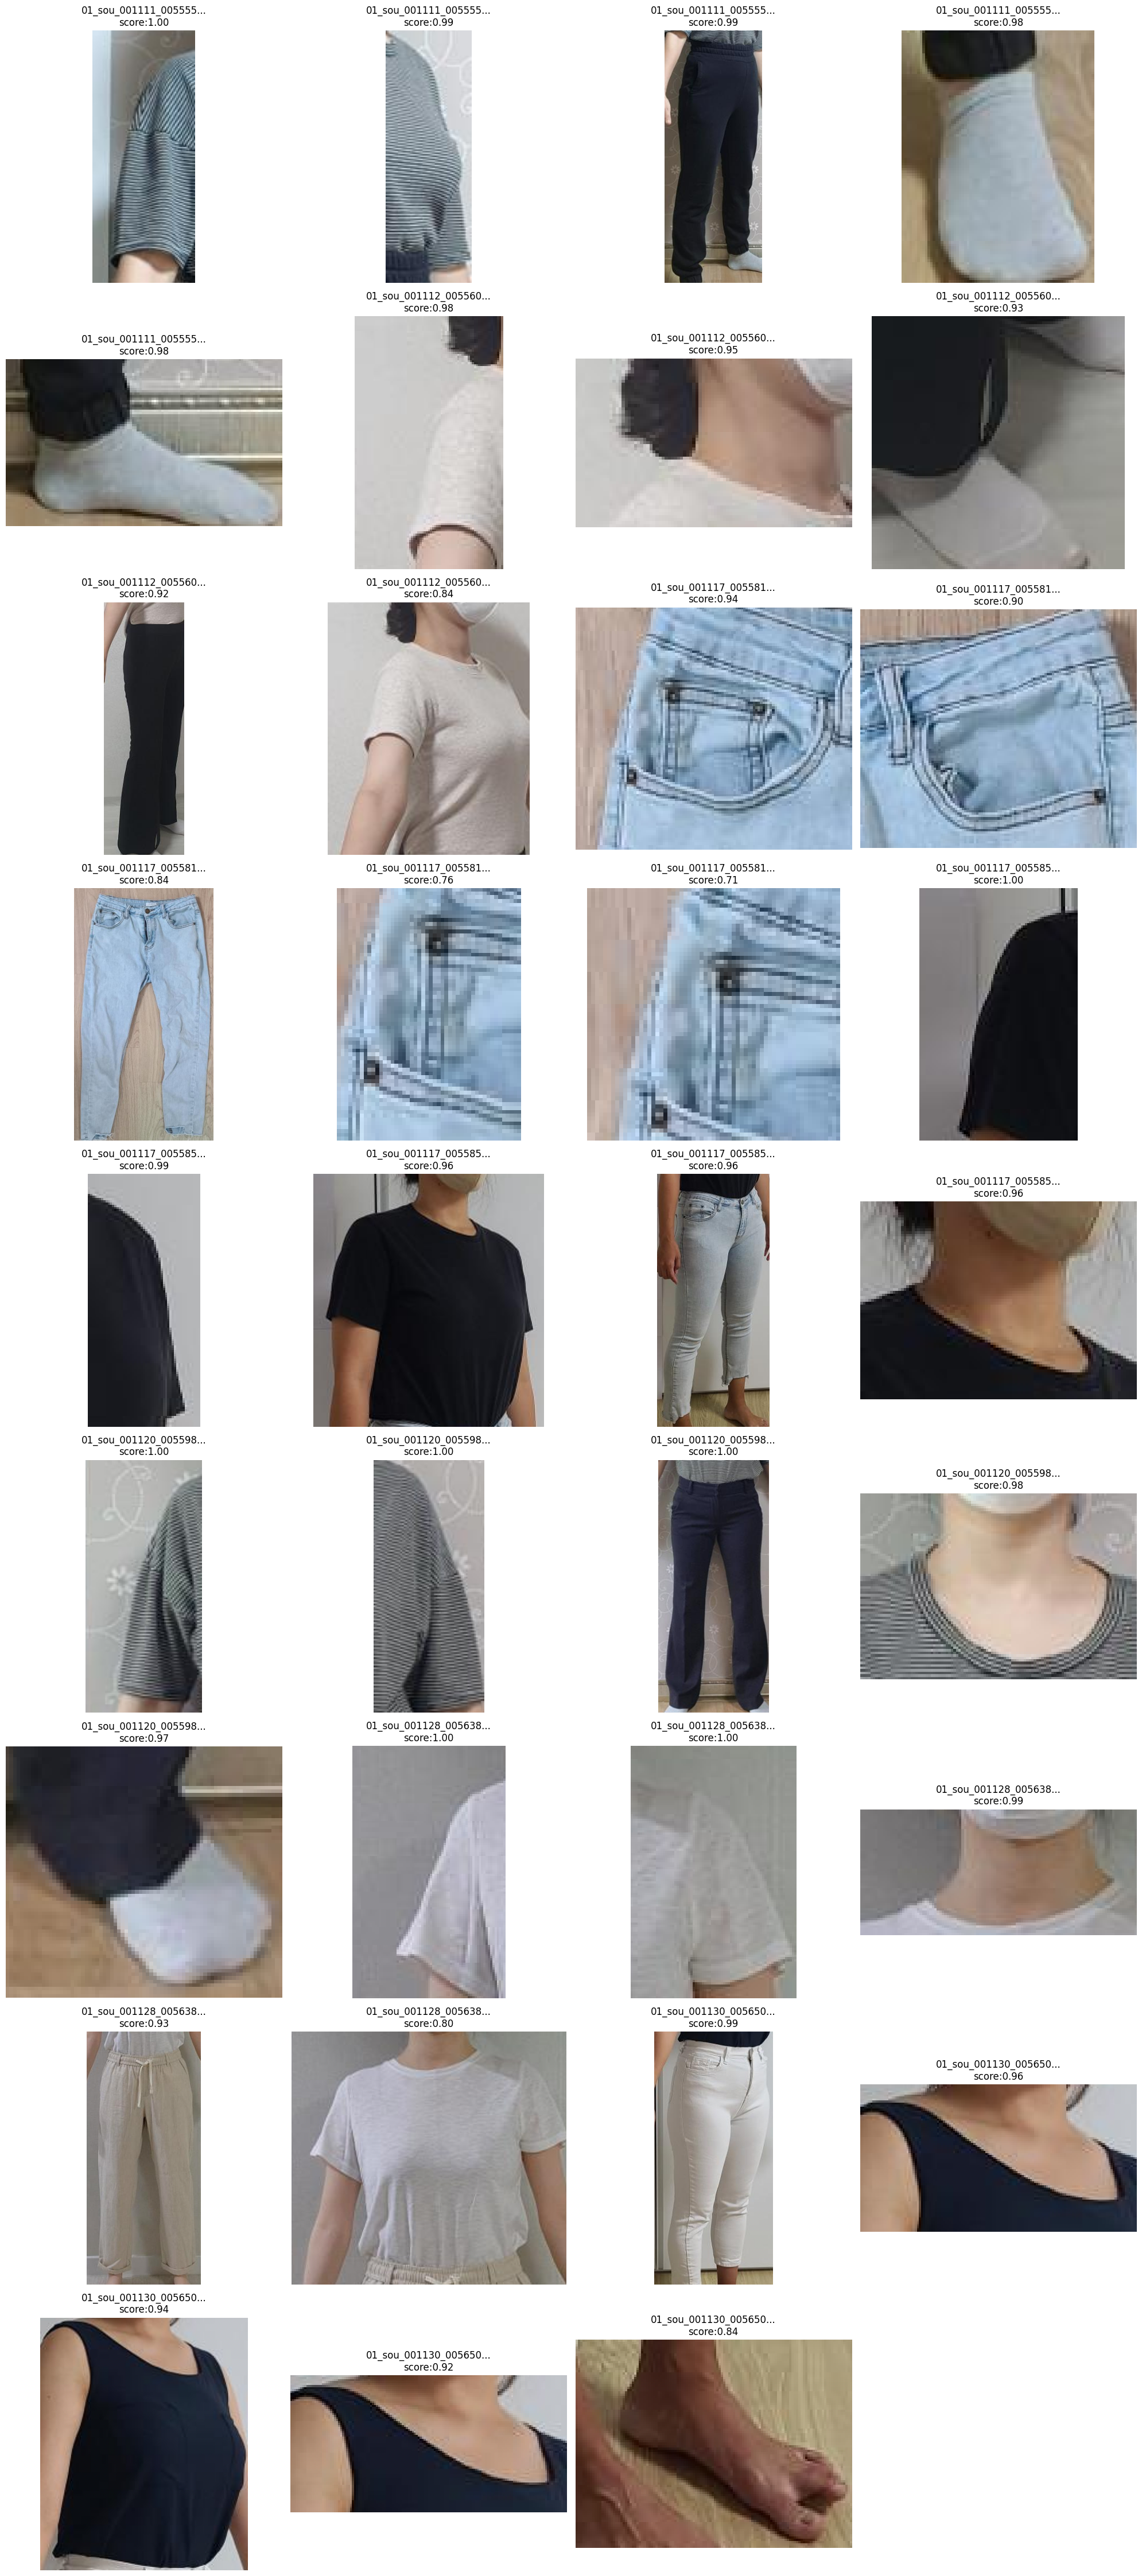

In [ ]:
# def visualize_all_crops(image_dir, score_thresh=0.6, cols=4):
#     images = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
#     all_crops = []
#     for img_file in images[:8]:  # 최대 8개
#         img_path = os.path.join(image_dir, img_file)
#         crops = run(img_path, score_thresh)
#         for crop in crops:
#             all_crops.append((img_file[:20], crop))
    
#     # 그리드
#     rows = (len(all_crops) + cols - 1) // cols
#     fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
#     if rows == 1:
#         axs = axs.reshape(1, -1)
#     axs = axs.ravel()
    
#     for i, (filename, crop_data) in enumerate(all_crops):
#         axs[i].imshow(crop_data["crop"])
#         axs[i].set_title(f'{filename}...\nscore:{crop_data["score"]:.2f}')
#         axs[i].axis('off')
    
#     for i in range(len(all_crops), len(axs)):
#         axs[i].axis('off')
    
#     plt.tight_layout()
#     plt.show()

# visualize_all_crops(r"C:\Users\ehjun\Documents\데브코스\AIModel\data\image\bottom")


In [60]:
# ============================================================
# YOLOS(Fashionpedia) → crop 1개만 선택(임베딩 안정화)
# - 요청 category: "TOP" 또는 "PANTS"
# - dress/jumpsuit(원피스/점프수트)는 "PANTS"로 들어오므로 PANTS 메인에 포함
# FashionCLIP(patrickjohncyh/fashion-clip) → Vision 임베딩(512)
# ============================================================

import torch
from PIL import Image
import requests
from io import BytesIO

from transformers import AutoImageProcessor, AutoModelForObjectDetection
from transformers import CLIPProcessor, CLIPVisionModelWithProjection

YOLOS_ID = "valentinafeve/yolos-fashionpedia"
FCLIP_ID = "patrickjohncyh/fashion-clip"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 요청 카테고리
REQ_TOP = "TOP"
REQ_PANTS = "PANTS"

# 라벨 그룹
TOP_MAIN = {
    "shirt, blouse", "top, t-shirt, sweatshirt", "sweater", "cardigan",
    "jacket", "vest", "coat", "cape"
}
TOP_PART = {"sleeve", "neckline", "collar", "lapel", "epaulette", "hood", "tie"}

BOTTOM_MAIN = {"pants", "shorts", "skirt"}
BOTTOM_PART = {"pocket", "buckle"}

ONEPIECE_MAIN = {"dress", "jumpsuit"}  # PANTS로 들어오지만, 판별/로그용으로 유지


# -----------------------
# Utils
# -----------------------
def load_image(img_path_or_url: str) -> Image.Image:
    if img_path_or_url.startswith("http://") or img_path_or_url.startswith("https://"):
        r = requests.get(img_path_or_url, timeout=30)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert("RGB")
    return Image.open(img_path_or_url).convert("RGB")

def union_boxes_xyxy(boxes):
    xs1 = [b[0] for b in boxes]; ys1 = [b[1] for b in boxes]
    xs2 = [b[2] for b in boxes]; ys2 = [b[3] for b in boxes]
    return (min(xs1), min(ys1), max(xs2), max(ys2))

def crop_pack(image, label_name, label_id, score, box_xyxy, pad):
    W, H = image.size
    x1, y1, x2, y2 = box_xyxy
    x1 = max(0, int(x1) - pad)
    y1 = max(0, int(y1) - pad)
    x2 = min(W, int(x2) + pad)
    y2 = min(H, int(y2) + pad)
    return {
        "crop": image.crop((x1, y1, x2, y2)),
        "score": float(score),
        "label_id": int(label_id),
        "label_name": label_name,
        "box_xyxy": (x1, y1, x2, y2),
    }

def pick_one_detection(dets, category):
    """
    dets: (label_name, score, label_id, box_xyxy) 리스트 (threshold 통과된 것들)
    return: (label_name, score, label_id, box_xyxy, pad_override, flags_dict) 또는 None
    """
    if not dets:
        return None

    if category == REQ_TOP:
        mains = [d for d in dets if d[0] in TOP_MAIN]
        if mains:
            ln, sc, lid, bx = max(mains, key=lambda x: x[1])  # score 최고 1개
            return (ln, sc, lid, bx, None, {"used_part_fallback": False, "is_onepiece": False})

        parts = [d for d in dets if d[0] in TOP_PART]
        if parts:
            u = union_boxes_xyxy([d[3] for d in parts])
            best_sc = max(d[1] for d in parts)
            # 파츠 기반 union은 작게 잡힐 수 있어 pad 크게
            return ("TOP_PART_union", best_sc, -1, u, 140, {"used_part_fallback": True, "is_onepiece": False})

        return None

    if category == REQ_PANTS:
        # PANTS 요청이면: 하의 + 원피스(dress/jumpsuit)까지 메인으로 취급
        mains = [d for d in dets if (d[0] in BOTTOM_MAIN) or (d[0] in ONEPIECE_MAIN)]
        if mains:
            ln, sc, lid, bx = max(mains, key=lambda x: x[1])  # score 최고 1개
            return (ln, sc, lid, bx, None, {"used_part_fallback": False, "is_onepiece": (ln in ONEPIECE_MAIN)})

        parts = [d for d in dets if d[0] in BOTTOM_PART]
        if parts:
            u = union_boxes_xyxy([d[3] for d in parts])
            best_sc = max(d[1] for d in parts)
            return ("BOTTOM_PART_union", best_sc, -1, u, 120, {"used_part_fallback": True, "is_onepiece": False})

        return None

    # category가 None/예상 밖이면 그냥 최고 score 1개
    ln, sc, lid, bx = max(dets, key=lambda x: x[1])
    return (ln, sc, lid, bx, None, {"used_part_fallback": False, "is_onepiece": False})


# -----------------------
# Detection + single crop
# -----------------------
@torch.no_grad()
def detect_one_crop(
    image: Image.Image,
    image_processor,
    det_model,
    score_thresh: float = 0.3,
    pad: int = 10,
    category: str | None = None,  # "TOP" / "PANTS"
):
    det_model.eval()

    inputs = image_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    outputs = det_model(**inputs)

    # HF object detection post-process: target_sizes는 (h,w) [web:75]
    target_sizes = torch.tensor([image.size[::-1]], device=DEVICE)
    results = image_processor.post_process_object_detection(
        outputs, threshold=score_thresh, target_sizes=target_sizes
    )[0]

    boxes  = results["boxes"].detach().cpu()
    scores = results["scores"].detach().cpu()
    labels = results["labels"].detach().cpu()

    if len(scores) == 0:
        return None

    dets = []
    for i in range(len(scores)):
        label_id = int(labels[i])
        label_name = det_model.config.id2label[label_id]  # [web:75]
        box_xyxy = tuple(map(int, boxes[i].tolist()))
        dets.append((label_name, float(scores[i]), label_id, box_xyxy))

    picked = pick_one_detection(dets, category)
    if picked is None:
        return None

    ln, sc, lid, bx, pad_override, flags = picked
    use_pad = pad_override if pad_override is not None else pad
    item = crop_pack(image, ln, lid, sc, bx, use_pad)
    item.update(flags)
    return item


# -----------------------
# Embedding (FashionCLIP weights, vision-only wrapper)
# -----------------------
@torch.no_grad()
def embed_one_crop(crop_item, clip_processor, clip_vision, l2_normalize=True):
    clip_vision.eval()

    inputs = clip_processor(images=crop_item["crop"], return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(DEVICE)

    out = clip_vision(pixel_values=pixel_values)
    emb = out.image_embeds[0].detach().cpu()  # (512,) [web:32][web:281]

    if l2_normalize:
        emb = emb / (emb.norm(p=2) + 1e-12)

    return {**crop_item, "embedding": emb}


# -----------------------
# Pipeline (항상 1개 임베딩 반환을 목표)
# -----------------------
def run(image_path_or_url: str, score_thresh=0.3, category: str | None = None):
    image_processor = AutoImageProcessor.from_pretrained(YOLOS_ID)
    det_model = AutoModelForObjectDetection.from_pretrained(YOLOS_ID).to(DEVICE)

    clip_processor = CLIPProcessor.from_pretrained(FCLIP_ID)
    clip_vision = CLIPVisionModelWithProjection.from_pretrained(FCLIP_ID).to(DEVICE)

    image = load_image(image_path_or_url)

    crop_item = detect_one_crop(
        image=image,
        image_processor=image_processor,
        det_model=det_model,
        score_thresh=score_thresh,
        pad=10,
        category=category,
    )

    if crop_item is None:
        print("No detections after filtering.")
        return None  # 1개 고정이므로 None 반환

    result = embed_one_crop(crop_item, clip_processor, clip_vision)

    print(
        f"label={result['label_name']} score={result['score']:.3f} "
        f"box={result['box_xyxy']} emb_dim={result['embedding'].shape[0]} "
        f"used_part_fallback={result['used_part_fallback']} is_onepiece={result['is_onepiece']}"
    )
    return result


# -----------------------
# Quick test (노트북)
# -----------------------
# img = r"C:\...\your.jpg"
# r = run(img, score_thresh=0.25, category="TOP")
# if r is not None:
#     r["crop"]


In [138]:
img = r"C:\Users\ehjun\Documents\데브코스\AIModel\data\image\onepiece\01_sou_000948_004739_wear_03-1onepiece(dress)_woman.jpg"


out = run(img, score_thresh=0.25, category="PANTS")  # out: dict 또는 None

if out is None:
    print("탐지 실패(크롭 없음)")
else:
    print(out["label_name"], out["score"], out["box_xyxy"], out["embedding"].shape)
    out["crop"]   # 크롭 이미지 보기


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1110.60it/s, Materializing param=visual_projection.weight]                                
CLIPVisionModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.embeddings.position_ids                         | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weigh

label=dress score=0.929 box=(200, 277, 502, 714) emb_dim=512 used_part_fallback=False is_onepiece=True
dress 0.9294947385787964 (200, 277, 502, 714) torch.Size([512])


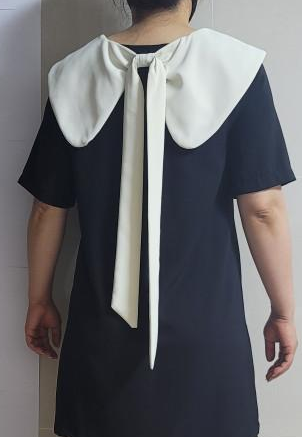

In [139]:
out["crop"]

In [1]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPVisionModelWithProjection

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FCLIP_ID = "patrickjohncyh/fashion-clip"

# 1. 모델 & 프로세서 로드
clip_processor = CLIPProcessor.from_pretrained(FCLIP_ID)
clip_vision = CLIPVisionModelWithProjection.from_pretrained(FCLIP_ID).to(DEVICE)
clip_vision.eval()

# 2. 이미지 로드
img_path = r"C:\Users\ehjun\Documents\데브코스\AIModel\data\image\onepiece\01_sou_000948_004739_wear_03-1onepiece(dress)_woman.jpg"
image = Image.open(img_path).convert("RGB")

# 3. 전처리
inputs = clip_processor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(DEVICE)

# 4. 임베딩 추출
with torch.no_grad():
    out = clip_vision(pixel_values=pixel_values)
    emb = out.image_embeds[0].cpu()  # (512,) [web:382]

# 5. L2 정규화 (선택)
emb = emb / (emb.norm(p=2) + 1e-12)

print("embedding shape:", emb.shape)
print("first 10 dims:", emb[:10])


c:\Users\ehjun\Documents\데브코스\dev_cor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 471.12it/s, Materializing param=visual_projection.weight]                                
CLIPVisionModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.

embedding shape: torch.Size([512])
first 10 dims: tensor([ 0.0079,  0.0851, -0.0008, -0.0631, -0.0098,  0.0067, -0.0809, -0.0430,
        -0.0286,  0.0436])


In [1]:
def connect_chroma_v1():
    """ChromaDB 1.x v2 API (Docker latest 호환)"""
    import chromadb
    
    # v2 API 클라이언트 (Python 1.0.15 + Docker latest)
    client = chromadb.HttpClient(
        host="localhost",
        port=8000
    )
    
    logger.info("✓ ChromaDB v2 API 연결 성공!")
    return client


In [2]:
import chromadb

client = chromadb.HttpClient(host="localhost", port=8000)
print("✅ Heartbeat:", client.heartbeat())  # 숫자 타임스탬프
print("컬렉션:", [c.name for c in client.list_collections()])

# fashion_products 컬렉션 확인
col = client.get_or_create_collection("fashion_products")
print("✅ Count =", col.count())
print("샘플:", col.get(limit=1))


ModuleNotFoundError: No module named 'chromadb'